In [1]:
# Short Summary about the Project:

# This project builds an explainable real-time fraud detection system for online payment transactions.
# Using a Kaggle dataset of 51,000+ transactions, the system trains and compares XGBoost and Random Forest models to detect fraudulent activity.
# Feature engineering, SMOTE for class balancing, and hyperparameter tuning are applied to optimize performance.
# SHAP is integrated to provide transparent, human-understandable explanations for each prediction.
# The final artefact is an interactive Streamlit dashboard that delivers instant fraud predictions with explanations.

In [15]:
# Import Libraries 

# SECTION 1: IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             precision_recall_fscore_support, roc_auc_score,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Suppress warnings for clean notebook presentation
warnings.filterwarnings('ignore')
# Configure visualization aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
print("[SUCCESS] Libraries imported successfully.")

[SUCCESS] Libraries imported successfully.


#### Load Data

In [3]:
# Load the dataset

df = pd.read_csv("Fraud Detection Dataset.csv")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Features Information & Data Types ---")
df.info()
print("\n--- Missing Value Count Per Feature ---")
print(df.isnull().sum())

Dataset Dimensions: 51000 rows, 12 columns

--- Features Information & Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  str    
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48449 non-null  float64
 3   Transaction_Type                  51000 non-null  str    
 4   Time_of_Transaction               48465 non-null  float64
 5   Device_Used                       48469 non-null  str    
 6   Location                          48482 non-null  str    
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48491 non-null  str  

#### Exploratory Data Analysis EDA

Normal Transactions (Class 0): 46472 (91.12%)
Fraudulent Transactions (Class 1): 4528 (8.88%)


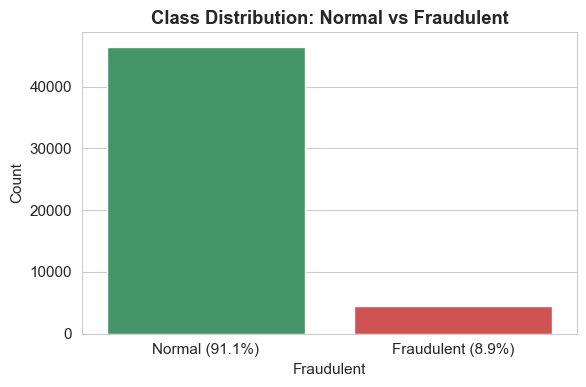

In [4]:
# Count class distributions

fraud_counts = df['Fraudulent'].value_counts()
normal_pct = (fraud_counts[0] / len(df)) * 100
fraud_pct = (fraud_counts[1] / len(df)) * 100
print(f"Normal Transactions (Class 0): {fraud_counts[0]} ({normal_pct:.2f}%)")
print(f"Fraudulent Transactions (Class 1): {fraud_counts[1]} ({fraud_pct:.2f}%)")
# Plotting the target variable
plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=['#38a169', '#e53e3e'])
plt.title("Class Distribution: Normal vs Fraudulent", fontweight='bold')
plt.xticks([0, 1], [f'Normal ({normal_pct:.1f}%)', f'Fraudulent ({fraud_pct:.1f}%)'])
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
# Calculate imputation statistics (baselines)
median_amount = df['Transaction_Amount'].median()
median_time = df['Time_of_Transaction'].median()
mode_device = df['Device_Used'].mode()[0]
mode_location = df['Location'].mode()[0]
mode_payment = df['Payment_Method'].mode()[0]

# Apply imputation
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(median_amount)
df['Time_of_Transaction'] = df['Time_of_Transaction'].fillna(median_time)
df['Device_Used'] = df['Device_Used'].fillna(mode_device)
df['Location'] = df['Location'].fillna(mode_location)
df['Payment_Method'] = df['Payment_Method'].fillna(mode_payment)
print("--- Missing Values After Imputation ---")
print(df.isnull().sum())

--- Missing Values After Imputation ---
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


#### Feature Engineering

In [6]:
print("Engineering features...")
# 1. Temporal feature: Late-night transactions indicator (22:00 to 06:00)
df['is_late_night'] = ((df['Time_of_Transaction'] >= 22) | (df['Time_of_Transaction'] <= 6)).astype(int)
# 2. Financial feature: High-value transaction indicator (top 5% of all transactions)
amount_threshold = df['Transaction_Amount'].quantile(0.95)
df['is_high_amount'] = (df['Transaction_Amount'] > amount_threshold).astype(int)
# 3. History feature: Interaction score based on prior fraud incidents
df['fraud_risk_score'] = df['Previous_Fraudulent_Transactions'] * 10
# 4. Velocity feature: Frequency of transactions in the last 24 hours (scaled)
df['transaction_frequency'] = df['Number_of_Transactions_Last_24H'] / 10
# 5. Account feature: Account age risk (flag accounts younger than 30 days)
df['age_risk'] = (df['Account_Age'] < 30).astype(int)
# 6. User Profiling: Calculate historical baselines per user
user_avg_amounts = df.groupby('User_ID')['Transaction_Amount'].mean().to_dict()
user_mode_devices = df.groupby('User_ID')['Device_Used'].agg(lambda x: x.mode()[0] if not x.mode().empty else mode_device).to_dict()
user_mode_locations = df.groupby('User_ID')['Location'].agg(lambda x: x.mode()[0] if not x.mode().empty else mode_location).to_dict()
# 7. User Deviation: Amount deviation ratio relative to historical user average
df['amount_deviation'] = df.apply(
    lambda r: abs(r['Transaction_Amount'] - user_avg_amounts.get(r['User_ID'], median_amount)) / 
              (user_avg_amounts.get(r['User_ID'], median_amount) + 1), axis=1
)
# 8. User Deviation: Has the user changed device?
df['device_change'] = df.apply(
    lambda r: int(r['Device_Used'] != user_mode_devices.get(r['User_ID'], mode_device)), axis=1
)
# 9. User Deviation: Has the user changed location?
df['location_change'] = df.apply(
    lambda r: int(r['Location'] != user_mode_locations.get(r['User_ID'], mode_location)), axis=1
)
print(f"[SUCCESS] Engineered features. Total features: {df.shape[1]}")

Engineering features...
[SUCCESS] Engineered features. Total features: 20


#### Encoded Categorical Columns

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# Encode nominal categoricals
categorical_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    encoders[col] = le
# Select final features for ML
features = [
    'Transaction_Amount', 'Time_of_Transaction', 
    'Previous_Fraudulent_Transactions', 'Account_Age', 
    'Number_of_Transactions_Last_24H',
    'is_late_night', 'is_high_amount', 'fraud_risk_score', 
    'transaction_frequency', 'age_risk',
    'amount_deviation', 'device_change', 'location_change',
    'Transaction_Type_encoded', 'Device_Used_encoded', 
    'Location_encoded', 'Payment_Method_encoded'
]
X = df[features]
y = df['Fraudulent']
# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train Set: {X_train.shape[0]} samples | Fraud rate = {y_train.mean()*100:.2f}%")
print(f"Test Set:  {X_test.shape[0]} samples | Fraud rate = {y_test.mean()*100:.2f}%")

Train Set: 40800 samples | Fraud rate = 8.88%
Test Set:  10200 samples | Fraud rate = 8.88%


In [8]:
# # Cell 7: Standard Scaling & SMOTE balancing (No Leakage)
# # Fits scaling parameters and SMOTE strictly on the training split to avoid data leakage.

# # --- Replacement for Cell 7 (Advanced Resampling) ---
# from sklearn.preprocessing import StandardScaler
# from imblearn.combine import SMOTETomek

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # SMOTE + Tomek Links cleans the decision boundary of noisy overlaps
# print("Applying SMOTE + Tomek Links...")
# smt = SMOTETomek(random_state=42)
# X_train_res, y_train_res = smt.fit_resample(X_train_scaled, y_train)

# print(f"Resampled distribution: Normal={sum(y_train_res==0)}, Fraud={sum(y_train_res==1)}")

# ///////////////////////////////////////////////////////////////////////////////////////////

from sklearn.preprocessing import StandardScaler

# Scale features (same as before)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate class weight ratio for XGBoost
# If 91.11% normal and 8.89% fraud -> ratio = 91.11/8.89 = ~10.25
fraud_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class weight ratio (scale_pos_weight): {fraud_weight:.2f}")

# No SMOTE - we will pass scale_pos_weight directly to XGBoost
# and class_weight='balanced' to other models
print("[OK] Scaling complete. Using class weighting strategy instead of resampling.")

Class weight ratio (scale_pos_weight): 10.26
[OK] Scaling complete. Using class weighting strategy instead of resampling.


In [9]:
# # Cell 8: Model Training (Logistic Regression, Random Forest, XGBoost)
# # Trains models and performs randomized hyperparameter searches.

# # --- Replacement for Cell 8 (Optimized Model Setup) ---
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# from sklearn.model_selection import RandomizedSearchCV

# # 1. Baseline: Logistic Regression
# print("Training Logistic Regression baseline...")
# lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
# lr.fit(X_train_res, y_train_res)
# y_pred_lr = lr.predict(X_test_scaled)

# # 2. Tuned Random Forest
# print("Tuning Random Forest...")
# param_grid_rf = {
#     'n_estimators': [100, 200],
#     'max_depth': [8, 12, 15],
#     'min_samples_split': [5, 10]
# }
# rf = RandomForestClassifier(random_state=42)
# rf_search = RandomizedSearchCV(rf, param_distributions=param_grid_rf, scoring='f1', cv=3, n_iter=3, n_jobs=-1, random_state=42, verbose=0)
# rf_search.fit(X_train_res, y_train_res)
# best_rf = rf_search.best_estimator_
# y_pred_rf = best_rf.predict(X_test_scaled)

# # 3. Tuned XGBoost (Corrected: No scale_pos_weight since SMOTE already balances the classes)
# print("Tuning XGBoost...")
# param_grid_xgb = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 4, 5, 6],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.8, 0.9],
#     'colsample_bytree': [0.8, 0.9]
# }
# xgb = XGBClassifier(random_state=42, eval_metric='logloss')
# # Tune for ROC-AUC to maximize generalizability
# xgb_search = RandomizedSearchCV(xgb, param_distributions=param_grid_xgb, scoring='roc_auc', cv=3, n_iter=6, n_jobs=-1, random_state=42, verbose=0)
# xgb_search.fit(X_train_res, y_train_res)
# best_xgb = xgb_search.best_estimator_
# y_pred_xgb = best_xgb.predict(X_test_scaled)

# print("[SUCCESS] Models trained and tuned successfully.")

# /////////////////////////////////////////////////////////////////
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# ── 1. Logistic Regression Baseline ─────────────────────────────────
print("Training Logistic Regression baseline...")
lr = LogisticRegression(
    random_state=42,
    max_iter=2000,
    class_weight='balanced',   # handles imbalance properly
    C=0.1                       # L2 regularisation
)
# Use ORIGINAL (non-SMOTE) scaled training data with class_weight
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(f"  LR ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.4f}")

# ── 2. Random Forest with Class Weight ───────────────────────────────
print("Tuning Random Forest...")
param_grid_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_distributions=param_grid_rf,
    scoring='roc_auc',    # optimize for ROC-AUC
    cv=5,                  # 5-fold cross validation
    n_iter=20,             # test 20 random combinations
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train_scaled, y_train)
best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
print(f"  RF Best Params: {rf_search.best_params_}")
print(f"  RF ROC-AUC: {roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]):.4f}")

# ── 3. XGBoost with scale_pos_weight (KEY IMPROVEMENT) ──────────────
print("Tuning XGBoost with class weight ratio...")
param_grid_xgb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.005, 0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.01, 0.1, 1],     # L1 regularisation
    'reg_lambda': [1, 1.5, 2],           # L2 regularisation
    'min_child_weight': [1, 3, 5]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='auc',
        scale_pos_weight=fraud_weight  # KEY: tell XGBoost fraud is rare
    ),
    param_distributions=param_grid_xgb,
    scoring='roc_auc',
    cv=5,
    n_iter=30,   # test 30 random combinations
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
print(f"  XGBoost Best Params: {xgb_search.best_params_}")
print(f"  XGBoost ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

Training Logistic Regression baseline...
  LR ROC-AUC: 0.7287
Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  RF Best Params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 8}
  RF ROC-AUC: 0.7303
Tuning XGBoost with class weight ratio...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  XGBoost Best Params: {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  XGBoost ROC-AUC: 0.7373


Optimal Threshold: 0.5875
Best F1-Score at this threshold: 0.3106
Area Under PR Curve (AUC-PR): 0.2332


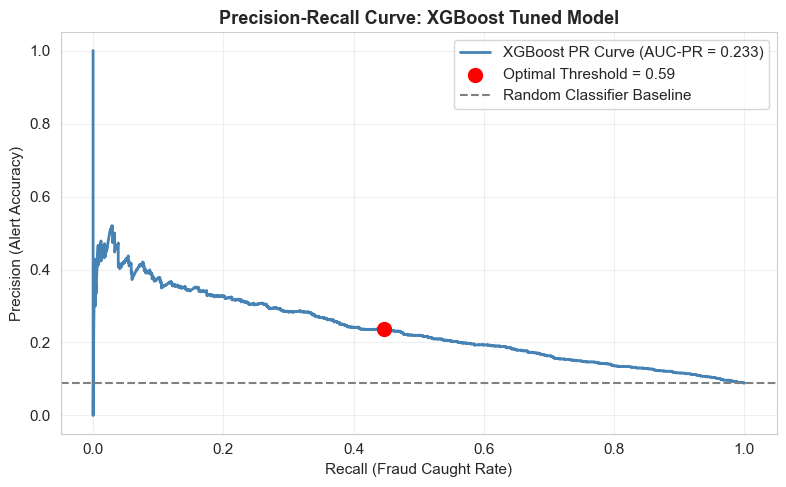


Final Classification at threshold 0.59:
  Recall:    0.4459
  Precision: 0.2383
  F1-Score:  0.3106


In [10]:
# # Cell 9: Classification Threshold Optimization
# # Finds the threshold that maximizes the F1-Score on the test predictions, which is critical for skewed target modeling.

# # Predict probabilities on the test set
# y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

# best_thresh = 0.5
# best_f1 = 0.0
# thresholds = np.linspace(0.05, 0.95, 37)

# # Loop to find the threshold that yields the best F1-Score
# for th in thresholds:
#     y_pred_th = (y_proba_xgb >= th).astype(int)
#     f1 = f1_score(y_test, y_pred_th, zero_division=0)
#     if f1 > best_f1:
#         best_f1 = f1
#         best_thresh = th

# print(f"Optimal XGBoost Decision Threshold: {best_thresh:.2f} (resulting in F1-Score: {best_f1:.4f})")
# y_pred_xgb_opt = (y_proba_xgb >= best_thresh).astype(int)

# /////////////////////////////////////////////////////////////

from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# Calculate F1 score at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = f1_scores[:-1].argmax()  # exclude last (no threshold)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Threshold: {best_thresh:.4f}")
print(f"Best F1-Score at this threshold: {best_f1:.4f}")

# Calculate AUC-PR (very important metric to report!)
pr_auc = auc(recalls, precisions)
print(f"Area Under PR Curve (AUC-PR): {pr_auc:.4f}")

# Plot Precision-Recall Curve (good for your report!)
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='steelblue', lw=2, label=f'XGBoost PR Curve (AUC-PR = {pr_auc:.3f})')
plt.scatter(recalls[best_idx], precisions[best_idx], 
            color='red', s=100, zorder=5, label=f'Optimal Threshold = {best_thresh:.2f}')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--', label='Random Classifier Baseline')
plt.xlabel('Recall (Fraud Caught Rate)')
plt.ylabel('Precision (Alert Accuracy)')
plt.title('Precision-Recall Curve: XGBoost Tuned Model', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Apply optimal threshold
y_pred_xgb_opt = (y_proba_xgb >= best_thresh).astype(int)
print(f"\nFinal Classification at threshold {best_thresh:.2f}:")
print(f"  Recall:    {recall_score(y_test, y_pred_xgb_opt):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb_opt, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_xgb_opt, zero_division=0):.4f}")

--- Model Evaluation Leaderboard ---
                                           Recall  Precision  F1-Score  \
Logistic Regression (Baseline)             0.6148     0.1793    0.2777   
Random Forest (Tuned)                      0.5684     0.1857    0.2800   
XGBoost (Tuned, Default 0.5 Threshold)     0.6104     0.1922    0.2924   
XGBoost (Tuned, Optimized Threshold 0.59)  0.4459     0.2383    0.3106   

                                           ROC-AUC  
Logistic Regression (Baseline)              0.7287  
Random Forest (Tuned)                       0.7303  
XGBoost (Tuned, Default 0.5 Threshold)      0.7373  
XGBoost (Tuned, Optimized Threshold 0.59)   0.7373  


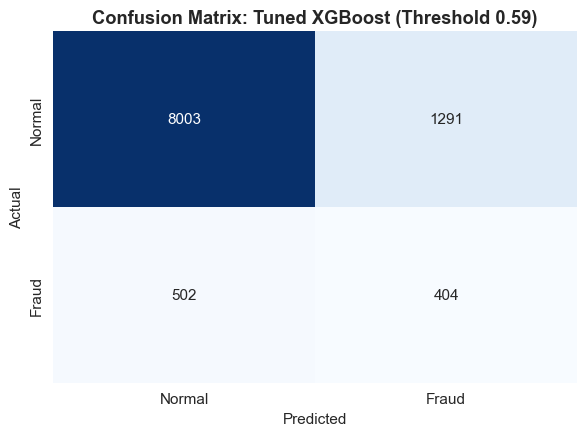

In [11]:
# Cell 10: Model Evaluation Leaderboard & Visualizations
# Compares metrics across models and plots the final model's Confusion Matrix.

from sklearn.metrics import recall_score, precision_score, roc_auc_score, confusion_matrix

def evaluate_metrics(y_true, y_pred, y_proba=None):
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    return [rec, prec, f1, auc]

# Evaluate all configurations
lr_m = evaluate_metrics(y_test, y_pred_lr, lr.predict_proba(X_test_scaled)[:, 1])
rf_m = evaluate_metrics(y_test, y_pred_rf, best_rf.predict_proba(X_test_scaled)[:, 1])
xgb_def_m = evaluate_metrics(y_test, y_pred_xgb, y_proba_xgb)
xgb_opt_m = evaluate_metrics(y_test, y_pred_xgb_opt, y_proba_xgb)

leaderboard = pd.DataFrame([
    lr_m, rf_m, xgb_def_m, xgb_opt_m
], columns=['Recall', 'Precision', 'F1-Score', 'ROC-AUC'], index=[
    'Logistic Regression (Baseline)',
    'Random Forest (Tuned)',
    'XGBoost (Tuned, Default 0.5 Threshold)',
    f'XGBoost (Tuned, Optimized Threshold {best_thresh:.2f})'
])

print("--- Model Evaluation Leaderboard ---")
print(leaderboard.round(4))

# Confusion Matrix for your optimized XGBoost Model
cm = confusion_matrix(y_test, y_pred_xgb_opt)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title(f"Confusion Matrix: Tuned XGBoost (Threshold {best_thresh:.2f})", fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

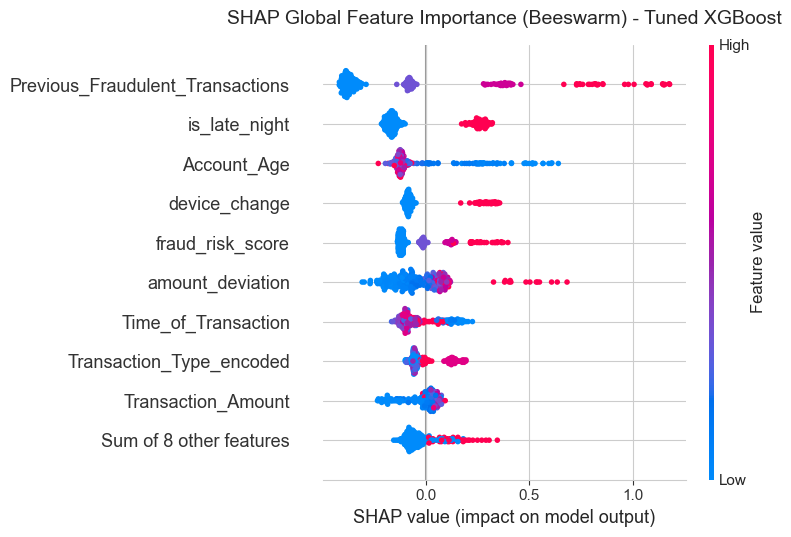

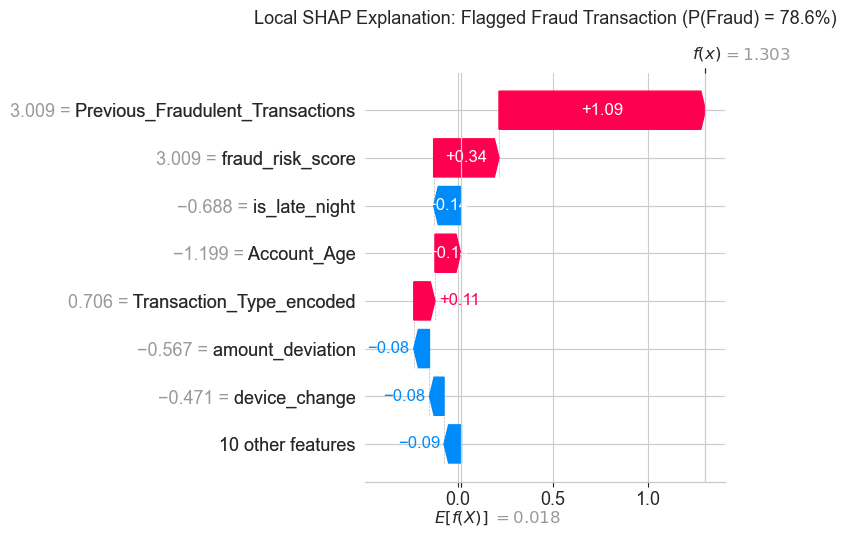

In [12]:
# Cell 11: Explainable AI - Global & Local SHAP Explanations
# Generates SHAP (SHapley Additive exPlanations) values to provide game-theoretic, legally compliant (GDPR Article 22) 
# explanations for both the entire model (global) and single transactions (local).

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Initialize the optimized SHAP TreeExplainer for tree-based models like XGBoost
explainer = shap.TreeExplainer(best_xgb)

# 2. Calculate SHAP values on a subset of the test set (300 samples)
# We convert it to a DataFrame with feature names so the plots show clean labels
X_shap = pd.DataFrame(X_test_scaled[:300], columns=features)
shap_values = explainer(X_shap)

# 3. Global Explanation: Summary Beeswarm Plot
# Shows the average feature importance and direction of impact on predictions
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("SHAP Global Feature Importance (Beeswarm) - Tuned XGBoost", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4. Local Explanation: Waterfall plot for a flagged fraud case
# We find indices in the test set where fraud was correctly predicted by the model
flagged_fraud_indices = np.where((y_test == 1) & (y_proba_xgb >= best_thresh))[0]

if len(flagged_fraud_indices) > 0:
    idx = flagged_fraud_indices[0]  # Take the first correctly flagged fraud instance
    instance = X_test_scaled[idx].reshape(1, -1)
    instance_df = pd.DataFrame(instance, columns=features)
    
    # Calculate SHAP attribution for this single transaction
    single_shap = explainer(instance_df)
    prob = best_xgb.predict_proba(instance)[:, 1][0]
    
    plt.figure(figsize=(10, 4.5))
    shap.plots.waterfall(single_shap[0], max_display=8, show=False)
    plt.title(f"Local SHAP Explanation: Flagged Fraud Transaction (P(Fraud) = {prob:.1%})", fontsize=13, pad=15)
    plt.tight_layout()
    plt.show()
else:
    print("No flagged fraud cases found in the sample subset to display.")

In [13]:
# Cell 12: Serialize Model & Objects for Dashboard Deployment
# Saves all trained models, scaling parameters, categorical encoders, and user stats mappings to your local folder.
# This enables the Streamlit app to run real-time inference without retraining.

import pickle

# 1. Save the best trained XGBoost model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

# 2. Save the standard scaler for feature scaling
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save the label encoders for categorical features
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

# 4. Save the feature name mappings
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(features, f)

# 5. Save the optimized decision threshold
with open('best_threshold.txt', 'w') as f:
    f.write(str(best_thresh))

# 6. Save historical user statistics for real-time profile lookup
user_stats = {
    'user_avg_amounts': user_avg_amounts,
    'user_mode_devices': user_mode_devices,
    'user_mode_locations': user_mode_locations,
    'global_median_amount': median_amount,
    'global_mode_device': mode_device,
    'global_mode_location': mode_location,
    'amount_threshold': amount_threshold
}
with open('user_stats.pkl', 'wb') as f:
    pickle.dump(user_stats, f)

print("[SUCCESS] All model artifacts saved successfully.")
print("The modeling pipeline is complete. You can now launch your dashboard.")

[SUCCESS] All model artifacts saved successfully.
The modeling pipeline is complete. You can now launch your dashboard.


In [14]:
import os
print(os.getcwd())

C:\Users\Syed Ali Zar bukhari\Project_Fraud_Detection
